In [7]:
import sys
sys.path.insert(0, '..')
from conditional_poisson_numpy import ConditionalPoisson
N, n = 10, 4
rng = np.random.default_rng(0)
w = rng.exponential(1.0, N)

cp = ConditionalPoisson.from_weights(n, w)

from display_utils import html_table
from IPython.display import HTML, display

rows = list(zip(
    range(N),
    [f'{wi:.4f}' for wi in w],
    [f'{pi:.4f}' for pi in cp.pi],
))
html_table(
    ['$i$', '$w_i$', '$\pi_i$'],
    rows,
    caption=f'$N={N}, \; n={n}, \;$ $\log Z = {cp.log_normalizer:.4f}, \;$ $\sum \pi_i = {cp.pi.sum():.4f}$',
)

$i$,$w_i$,$\pi_i$
0,0.6799,0.3432
1,1.0196,0.4559
2,0.0198,0.0127
3,0.0023,0.0015
4,0.5503,0.2912
5,1.6299,0.5923
6,0.6736,0.3408
7,0.7553,0.3711
8,2.8168,0.7302
9,6.0578,0.8612


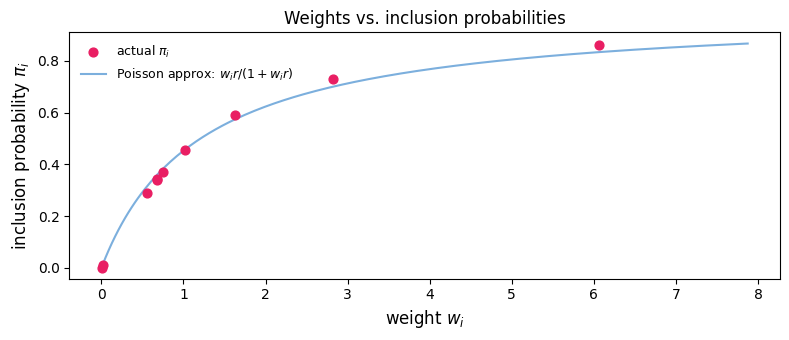

In [8]:
pl.figure(figsize=(8, 3.5))

# Scatter: actual (w_i, pi_i) pairs
pl.scatter(w, cp.pi, color='#E91E63', s=40, zorder=3, label='actual $\\pi_i$')

# Poisson approximation: pi_i ≈ w_i / (1 + w_i) * (n / sum p_i)
# This is the logit warm start used for fitting
from conditional_poisson_torch import _find_r
import torch
r = _find_r(torch.tensor(w, dtype=torch.float64), n)
w_grid = np.linspace(max(w.min() * 0.5, 0.01), w.max() * 1.3, 200)
pi_approx = w_grid * r / (1 + w_grid * r)
pl.plot(w_grid, pi_approx, '-', color='#5b9bd5', alpha=0.8, lw=1.5,
        label='Poisson approx: $w_i r / (1 + w_i r)$')

pl.xlabel('weight $w_i$', fontsize=12)
pl.ylabel('inclusion probability $\\pi_i$', fontsize=12)
pl.title('Weights vs. inclusion probabilities', fontsize=12)
pl.legend(fontsize=9, frameon=False)
pl.tight_layout()
pl.show()


In [9]:
M = 100_000
samples = cp.sample(M, rng=rng)

from IPython.display import HTML, display
display(HTML(
    f'<b>{M:,} samples</b> of size <b>{samples.shape[1]}</b> '
    f'&mdash; first 5: '
    + ', '.join('{' + ','.join(map(str, s)) + '}' for s in samples[:5])
))

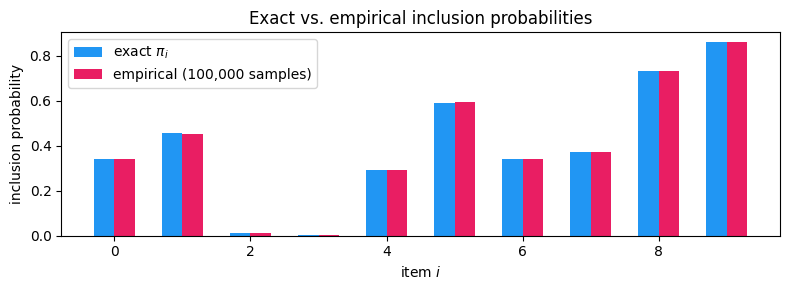

In [10]:
pi_emp = np.bincount(samples.ravel(), minlength=N) / M

pl.figure(figsize=(8, 3))
ix = np.arange(N)
pl.bar(ix - 0.15, cp.pi, width=0.3, label='exact $\pi_i$', color='#2196F3')
pl.bar(ix + 0.15, pi_emp, width=0.3, label=f'empirical ({M:,} samples)', color='#E91E63')
pl.xlabel('item $i$')
pl.ylabel('inclusion probability')
pl.legend()
pl.title('Exact vs. empirical inclusion probabilities')
pl.tight_layout()

In [11]:
# Target: the inclusion probabilities from our earlier example
pi_star = cp.pi.copy()

# Fit from scratch
cp_fit = ConditionalPoisson.fit(pi_star, n, verbose=True)

  iter   0:  max|pi*-pi| = 3.332e-02
  iter   1:  max|pi*-pi| = 2.606e-03
  iter   2:  max|pi*-pi| = 2.036e-05
  iter   3:  max|pi*-pi| = 1.994e-09
  iter   4:  max|pi*-pi| = 7.661e-15


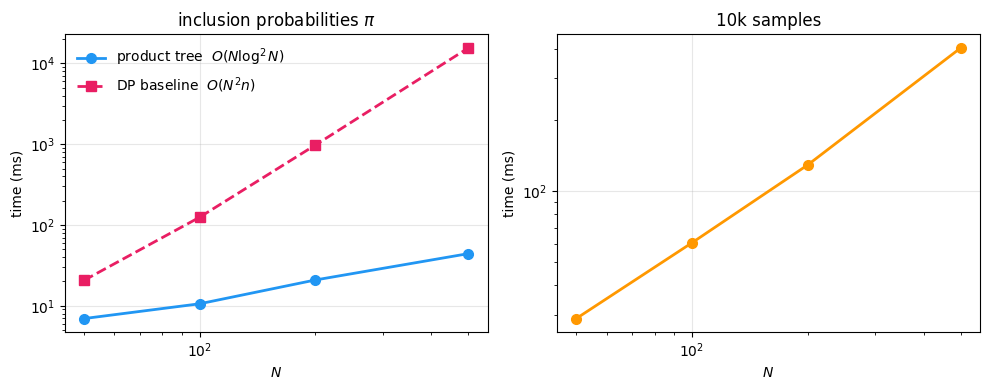

In [ ]:
import time
import torch
from conditional_poisson_torch import compute_pi as fft_pi

def dp_pi(w, n):
    """O(N^2 n) DP for inclusion probabilities (baseline)."""
    N = len(w)
    e = np.zeros((N + 1, n + 1))
    e[0, 0] = 1.0
    for m in range(N):
        e[m + 1, 0] = e[m, 0]
        for k in range(1, n + 1):
            e[m + 1, k] = e[m, k] + w[m] * e[m, k - 1]
    Z = e[N, n]
    pi = np.empty(N)
    for i in range(N):
        ei = np.zeros(n)
        ei[0] = 1.0
        for m in range(N):
            if m == i: continue
            for k in range(min(n - 1, m + 1), 0, -1):
                ei[k] += w[m] * ei[k - 1]
        pi[i] = w[i] * ei[n - 1] / Z
    return pi

sizes = [(50, 20), (100, 40), (200, 80), (500, 200), (1000, 400), (2000, 800)]
Ns, dp_t, tree_t, fft_t, samp_t = [], [], [], [], []

for N_t, n_t in sizes:
    w_t = rng.exponential(1.0, N_t)
    theta_t = torch.tensor(np.log(w_t), dtype=torch.float64)
    v_t = torch.randn(N_t, dtype=torch.float64)
    cp_t = ConditionalPoisson.from_weights(n_t, w_t)
    reps = max(3, 200 // max(1, N_t // 50))

    # DP baseline (skip for large N)
    if N_t <= 500:
        dp_reps = max(1, reps // 3)
        t0 = time.perf_counter()
        for _ in range(dp_reps): dp_pi(w_t, n_t)
        dp_t.append((time.perf_counter() - t0) / dp_reps * 1000)
    else:
        dp_t.append(None)

    # NumPy product tree
    for _ in range(3): cp_t._cache.clear(); cp_t.pi
    t0 = time.perf_counter()
    for _ in range(reps): cp_t._cache.clear(); cp_t.pi
    tree_t.append((time.perf_counter() - t0) / reps * 1000)

    # FFT (PyTorch)
    for _ in range(3): fft_pi(theta_t, n_t)
    t0 = time.perf_counter()
    for _ in range(reps): fft_pi(theta_t, n_t)
    fft_t.append((time.perf_counter() - t0) / reps * 1000)

    # Sampling (10k samples)
    t0 = time.perf_counter()
    cp_t.sample(10_000, rng=rng)
    samp_t.append((time.perf_counter() - t0) * 1000)

    Ns.append(N_t)

fig, (ax1, ax2) = pl.subplots(1, 2, figsize=(10, 4))

# Left: computing π — all methods
dp_ns = [N for N, t in zip(Ns, dp_t) if t is not None]
dp_ts = [t for t in dp_t if t is not None]
ax1.loglog(dp_ns, dp_ts, 's--', color='#999', label='DP baseline $\mathcal{O}(N^2 n)$', lw=1.5, ms=6)
ax1.loglog(Ns, tree_t, 'o-', color='#5b9bd5', label='NumPy tree $\mathcal{O}(N \log^2 n)$', lw=2, ms=6)
ax1.loglog(Ns, fft_t, '^-', color='#c0504d', label='PyTorch FFT $\mathcal{O}(N \log^2 n)$', lw=2, ms=6)
ax1.set_xlabel('$N$')
ax1.set_ylabel('time (ms)')
ax1.legend(frameon=False, fontsize=9)
ax1.grid(True, alpha=0.2)

# Right: sampling
ax2.loglog(Ns, samp_t, 'o-', color='#5b9bd5', label='product tree (10k samples)', lw=2, ms=6)
# Add reference line for O(n log N) per sample × 10k
ref = [Ns[0] * np.log(Ns[0])] * len(Ns)
ref = [10000 * n_t * np.log(N_t) / (sizes[0][1] * np.log(sizes[0][0])) * samp_t[0] for (N_t, n_t) in sizes]
ax2.loglog(Ns, ref, '--', color='#ccc', label='$\mathcal{O}(n \log N)$ reference', lw=1.5)
ax2.set_xlabel('$N$')
ax2.set_ylabel('time (ms)')
ax2.set_title('Drawing 10k Samples')
ax2.legend(frameon=False, fontsize=9)
ax2.grid(True, alpha=0.2)

pl.tight_layout()
pl.show()

In [ ]:
# Numerical validation: why the exact choice of r matters
import torch, math
from conditional_poisson_torch import _find_r
from conditional_poisson import ConditionalPoisson
from display_utils import html_table

def fft_mul(a, b):
    m = len(a) + len(b) - 1
    return torch.fft.irfft(torch.fft.rfft(a, n=m) * torch.fft.rfft(b, n=m), n=m)

def build_tree_fft(w):
    polys = [torch.tensor([1.0, wi.item()], dtype=torch.float64) for wi in w]
    while len(polys) > 1:
        nxt = [fft_mul(polys[i], polys[i+1]) for i in range(0, len(polys)-1, 2)]
        if len(polys) % 2: nxt.append(polys[-1])
        polys = nxt
    return polys[0]

def test_r(w, n, label, r, log_Z_true):
    poly = build_tree_fft(w * r)
    c = poly[n].item()
    if c <= 0: return (label, f'{r:.2e}', '—', 'negative coeff')
    dr = poly.abs().max().item() / abs(c)
    err = abs(math.log(c) - n * math.log(r) - log_Z_true)
    return (label, f'{r:.2e}', f'{dr:.0e}', f'{err:.0e}')

rows = []
for seed, spread in [(0, 1.0), (1, 3.0)]:
    torch.manual_seed(seed)
    N_v, n_v = 200, 10
    w = torch.exp(spread * torch.randn(N_v, dtype=torch.float64))
    Z_true = ConditionalPoisson.from_weights(n_v, w.numpy()).log_normalizer
    regime = f'spread={spread}'
    r_opt = _find_r(w, n_v)
    rows.append(test_r(w, n_v, f'$r=1$ ({regime})', 1.0, Z_true))
    rows.append(test_r(w, n_v, f'$r=n/W$ ({regime})', n_v / w.sum().item(), Z_true))
    rows.append(test_r(w, n_v, f'$r=r^*$ ({regime})', r_opt, Z_true))

html_table(
    ['scaling rule', '$r$', 'dynamic range', '$|\\log Z$ error$|$'],
    rows,
    caption='FFT product tree (N=200, n=10): contour radius comparison'
)

scaling rule,$r$,dynamic range,|$\log Z$ error|
$r=1$ (spread=1.0),1.00e+00,1e+16,8e+01
$r=n/W$ (spread=1.0),3.15e-02,1e+00,7e-15
$r=r^*$ (spread=1.0),3.56e-02,1e+00,1e-14
$r=1$ (spread=3.0),1.00e+00,1e+16,2e+02
$r=n/W$ (spread=3.0),7.43e-04,8e+01,2e-13
$r=r^*$ (spread=3.0),3.04e-03,1e+00,4e-14
